# G01 — Exploration du Dataset IMDb
**Projet** : Fine-tuning de Transformers  
**Groupe** : G01 | Dataset : D01 (IMDb) | Modèle : M01 (DistilBERT) | P01 Optimiseurs | Random Search

Ce notebook explore le dataset avant l'entraînement.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

sns.set_theme(style='whitegrid', font_scale=1.1)
print('Librairies chargées ✓')

Librairies chargées ✓


## 1. Chargement du dataset IMDb

In [2]:
dataset = load_dataset('imdb')
print('Splits disponibles :', list(dataset.keys()))
print('Train :', len(dataset['train']), 'exemples')
print('Test  :', len(dataset['test']),  'exemples')

Splits disponibles : ['train', 'test', 'unsupervised']
Train : 25000 exemples
Test  : 25000 exemples


## 2. Distribution des classes

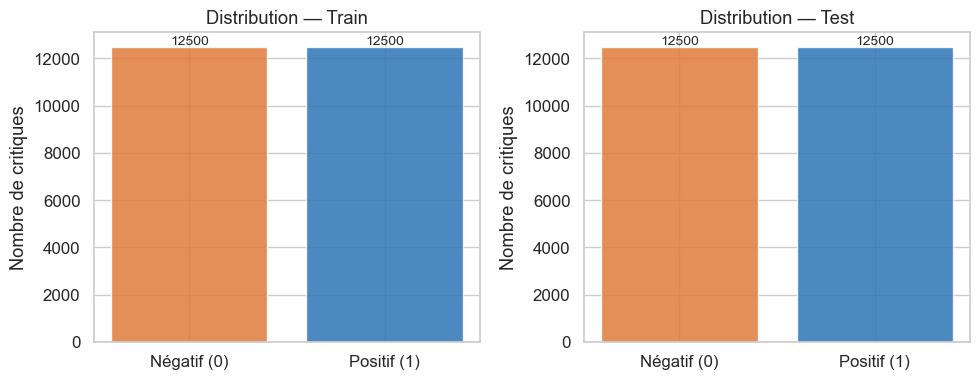

Le dataset est parfaitement équilibré (50% pos / 50% nég).


In [3]:
labels_train = dataset['train']['label']
labels_test  = dataset['test']['label']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, labels, title in zip(axes,
                              [labels_train, labels_test],
                              ['Train', 'Test']):
    counts = pd.Series(labels).value_counts().sort_index()
    ax.bar(['Négatif (0)', 'Positif (1)'], counts.values,
           color=['#E07B39', '#2E75B6'], alpha=0.85)
    ax.set_title(f'Distribution — {title}')
    ax.set_ylabel('Nombre de critiques')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 100, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()
print('Le dataset est parfaitement équilibré (50% pos / 50% nég).')

## 3. Distribution des longueurs de texte

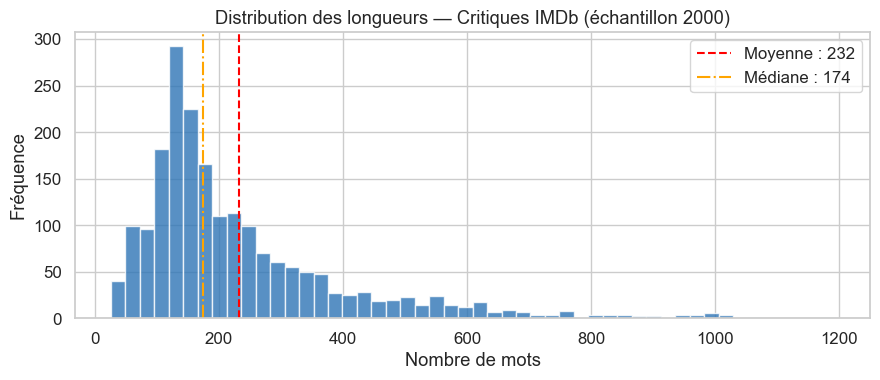

Longueur moyenne  : 232.2 mots
Longueur médiane  : 173.5 mots
Longueur maximale : 1192 mots
→ Troncature à 256 tokens couvre la majorité des exemples.


In [4]:
# Mesure en nombre de mots (proxy de la longueur)
import random
random.seed(42)
sample_idx = random.sample(range(len(dataset['train'])), 2000)
lengths    = [len(dataset['train'][i]['text'].split()) for i in sample_idx]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lengths, bins=50, color='#2E75B6', alpha=0.8, edgecolor='white')
ax.axvline(np.mean(lengths),  color='red',    linestyle='--',
           label=f'Moyenne : {np.mean(lengths):.0f}')
ax.axvline(np.median(lengths), color='orange', linestyle='-.',
           label=f'Médiane : {np.median(lengths):.0f}')
ax.set_xlabel('Nombre de mots')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution des longueurs — Critiques IMDb (échantillon 2000)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Longueur moyenne  : {np.mean(lengths):.1f} mots')
print(f'Longueur médiane  : {np.median(lengths):.1f} mots')
print(f'Longueur maximale : {max(lengths)} mots')
print(f'→ Troncature à 256 tokens couvre la majorité des exemples.')

## 4. Exemples de critiques

In [5]:
label_names = {0: 'Négatif ❌', 1: 'Positif ✅'}

for label in [0, 1]:
    ex = next(e for e in dataset['train'] if e['label'] == label)
    print(f"\n{'─'*60}")
    print(f"Label : {label_names[label]}")
    print(f"Texte : {ex['text'][:300]}…")
print(f"{'─'*60}")


────────────────────────────────────────────────────────────
Label : Négatif ❌
Texte : I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h…

────────────────────────────────────────────────────────────
Label : Positif ✅
Texte : Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the more strik…
────────────────────────────────────────────────────────────


## 5. Tokenisation avec DistilBERT

Tokens (tronqué à 256) : 256
Tokens spéciaux : [CLS] = 101, [SEP] = 102


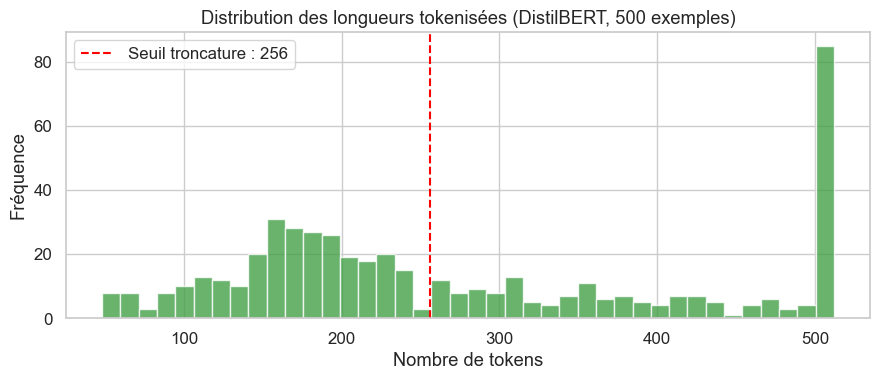

→ 44.2% des critiques dépassent 256 tokens.


In [6]:
from transformers import AutoTokenizer

tokenizer  = AutoTokenizer.from_pretrained('distilbert-base-uncased')
sample_txt = dataset['train'][0]['text']

encoded = tokenizer(sample_txt, truncation=True, max_length=256)
print(f'Tokens (tronqué à 256) : {len(encoded["input_ids"])}')
print(f'Tokens spéciaux : [CLS] = {tokenizer.cls_token_id}, [SEP] = {tokenizer.sep_token_id}')

# Distribution des longueurs tokenisées
tok_lengths = [
    len(tokenizer(dataset['train'][i]['text'], truncation=True,
                  max_length=512)['input_ids'])
    for i in sample_idx[:500]
]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(tok_lengths, bins=40, color='#43A047', alpha=0.8, edgecolor='white')
ax.axvline(256, color='red', linestyle='--', label='Seuil troncature : 256')
ax.set_xlabel('Nombre de tokens')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution des longueurs tokenisées (DistilBERT, 500 exemples)')
ax.legend()
plt.tight_layout()
plt.show()

pct_truncated = sum(1 for l in tok_lengths if l >= 256) / len(tok_lengths) * 100
print(f'→ {pct_truncated:.1f}% des critiques dépassent 256 tokens.')

## 6. Récapitulatif pour le rapport

In [7]:
print('─' * 50)
print('RÉCAPITULATIF — Dataset IMDb (D01)')
print('─' * 50)
print(f'  Taille totale  : {len(dataset["train"]) + len(dataset["test"]):,} critiques')
print(f'  Classes        : 2 (0=Négatif, 1=Positif)')
print(f'  Équilibre      : Parfait (50/50)')
print(f'  Langue         : Anglais')
print(f'  Max seq length : 256 tokens (troncature ~{pct_truncated:.0f}%)')
print(f'  Sous-échantil. : 1000 train / 200 val / 250 test par classe')
print('─' * 50)

──────────────────────────────────────────────────
RÉCAPITULATIF — Dataset IMDb (D01)
──────────────────────────────────────────────────
  Taille totale  : 50,000 critiques
  Classes        : 2 (0=Négatif, 1=Positif)
  Équilibre      : Parfait (50/50)
  Langue         : Anglais
  Max seq length : 256 tokens (troncature ~44%)
  Sous-échantil. : 1000 train / 200 val / 250 test par classe
──────────────────────────────────────────────────
